<a href="https://colab.research.google.com/github/debi201326/Shallow-and-Deep-Learning/blob/main/SDL_Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building a Logistic Regression Model Using a Single MLP to Predict Whether an Email is Spam or Not for Binary Classification.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("emails.csv")

In [3]:
X_text = df['text']
y = df['spam']

In [4]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
X = vectorizer.fit_transform(X_text)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(), activation='logistic',
    max_iter=500, random_state=42
)

In [8]:
mlp.fit(X_train_scaled, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(), max_iter=500,
              random_state=42)

In [9]:
y_pred = mlp.predict(X_test_scaled)
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]

In [10]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9860


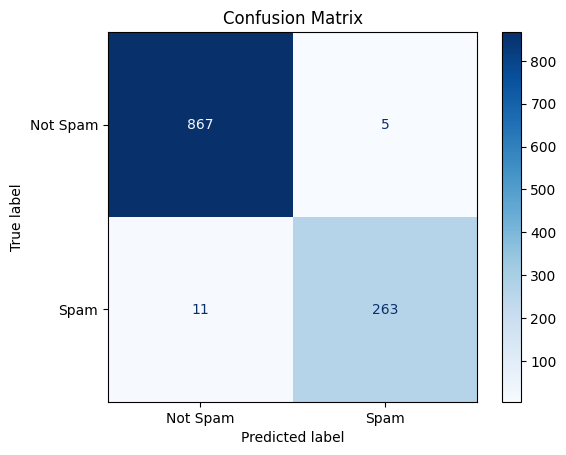

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

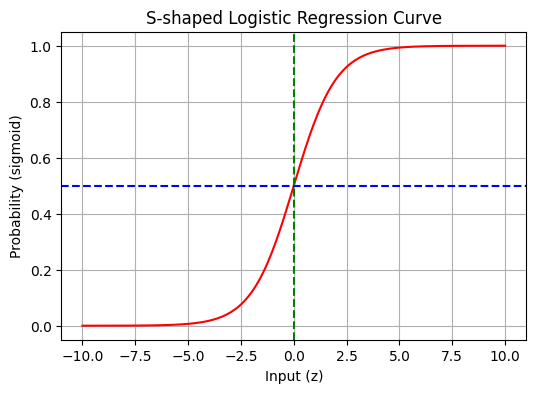

In [14]:
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.plot(z, sigmoid, color="red")
plt.axhline(y=0.5, color='blue', linestyle='--')
plt.axvline(x=0, color='green', linestyle='--')
plt.title("S-shaped Logistic Regression Curve")
plt.xlabel("Input (z)")
plt.ylabel("Probability (sigmoid)")
plt.grid(True)
plt.show()